# UMaze Diffuser — Training + DPM-Solver-1 Sampling

Trains a VE-SDE score model on the preprocessed PointMaze UMaze-v2 trajectory dataset
(`Diffuser/data/umaze_v2/`) using the same `TemporalUnet` + `VEDiffusion` pipeline
as the circles notebook, then samples with DPM-Solver-1 and renders trajectories
overlaid on the U-maze walls.

## 1. Imports

In [1]:
import sys, os, copy, time
import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

# notebooks/ → SafeDPMSolverProject/
PROJECT_ROOT = os.path.dirname(os.getcwd())
# parent of SafeDPMSolverProject/ → makes 'SafeDPMSolver' package importable
PARENT = os.path.dirname(PROJECT_ROOT)

for p in [PARENT, PROJECT_ROOT, os.path.join(PROJECT_ROOT, 'Diffuser')]:
    if p not in sys.path:
        sys.path.insert(0, p)

# score_net / ve_diffusion come from C:\Users\Owner\SafeDPMSolver\ (sibling package)
from SafeDPMSolver.models.score_net    import TemporalUnet
from SafeDPMSolver.models.ve_diffusion import VEDiffusion

# samplers.py and maze_dataset.py live in SafeDPMSolverProject (not the SafeDPMSolver package)
from models.samplers  import dpm_solver_1_sample
from maze_dataset     import MazeDataset, render_maze_ax

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)


device: cuda


## 2. Configuration

In [2]:
# ---- Model ----
UNET_INPUT_DIM = 32
DIM_MULTS      = (1, 2, 4)

# ---- VE noise schedule ----
SIGMA_MIN = 0.01
SIGMA_MAX = 10.0
N_LEVELS  = 1000

# ---- Training ----
BATCH_SIZE       = 128
LR               = 3e-4
TOTAL_STEPS      = 100_000
EMA_DECAY        = 0.995
EMA_START_STEP   = 1_000
EMA_UPDATE_EVERY = 10

# ---- Sampling ----
N_SAMPLE_STEPS = 25    # DPM-Solver-1 denoising steps

# ---- Logging / preview ----
LOG_EVERY     = 500    # print loss
PREVIEW_EVERY = 2_000  # render sample trajectories
SAVE_EVERY    = 10_000 # checkpoint

## 3. Dataset

In [3]:
DATA_DIR = os.path.join(PROJECT_ROOT, 'Diffuser', 'data', 'umaze_v2')

ds = MazeDataset(DATA_DIR, xy_only=True)   # [N, H, 2] normalised (x, y only)
dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

T_STEPS = ds.horizon   # 128
print(ds)
print(f'T_STEPS={T_STEPS}, batches per epoch={len(dl)}')

MazeDataset(env='D4RL/pointmaze/umaze-v2', n=13210, horizon=64, obs_dim=2, xy_only=True)
T_STEPS=64, batches per epoch=103


## 4. Model Setup

In [4]:
score_net = TemporalUnet(
    state_dim=2,
    T_steps=T_STEPS,
    unet_input_dim=UNET_INPUT_DIM,
    dim_mults=DIM_MULTS,
).to(device)

ve = VEDiffusion(
    model=score_net,
    sigma_min=SIGMA_MIN,
    sigma_max=SIGMA_MAX,
    n_levels=N_LEVELS,
).to(device)

ema_model = copy.deepcopy(score_net).to(device)
for p in ema_model.parameters():
    p.requires_grad_(False)

optimizer = torch.optim.Adam(score_net.parameters(), lr=LR)

n_params = sum(p.numel() for p in score_net.parameters())
print(f'TemporalUnet params: {n_params:,}')

TemporalUnet params: 1,000,278


## 5. Training + Live Preview

- `xs = batch[:, 0, :]`  — start of each window (normalised)
- `xg = batch[:, -1, :]` — end of each window (normalised)
- DPM-Solver-1 preview every `PREVIEW_EVERY` steps; unnormalised back to world coords for rendering.

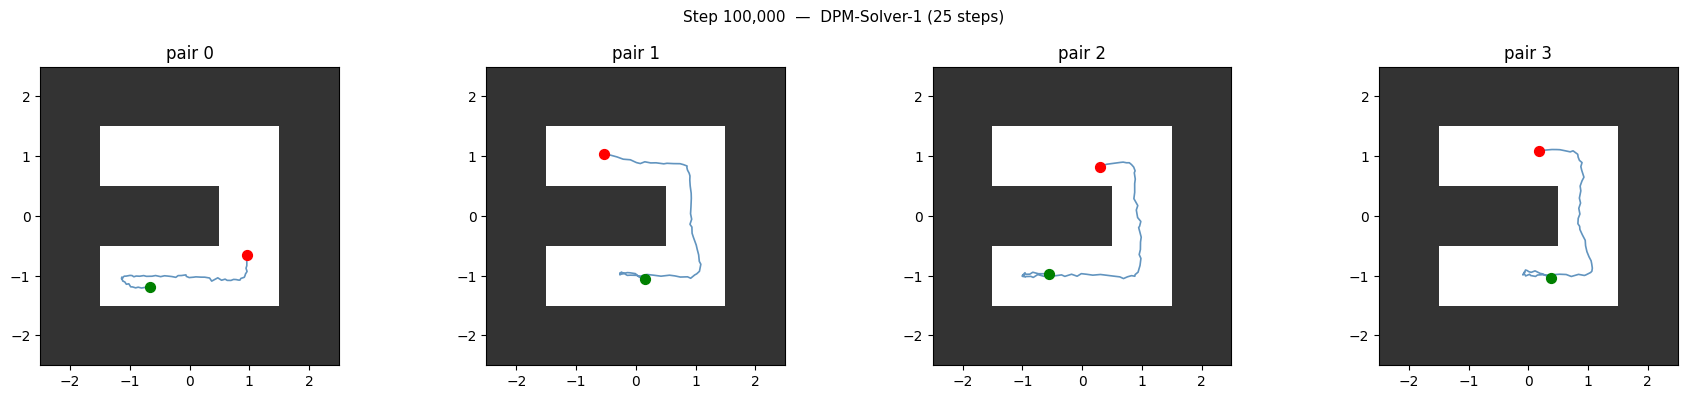

  checkpoint saved → c:\Users\Owner\SafeDPMSolverProject\checkpoints\ve_unet_umaze_diffuser.pt
Training complete.


In [5]:
import itertools

# ---- Fixed preview pairs (4 random windows from the dataset) ----
rng_fix   = np.random.default_rng(42)
fix_idx   = rng_fix.choice(len(ds), size=4, replace=False).tolist()
fix_batch = torch.stack([ds[i] for i in fix_idx])   # [4, T, 2]
fix_xs = fix_batch[:, 0, :].to(device)               # [4, 2] normalised start
fix_xg = fix_batch[:, -1, :].to(device)              # [4, 2] normalised goal


def preview(step):
    ema_model.eval()
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle(f'Step {step:,}  —  DPM-Solver-1 ({N_SAMPLE_STEPS} steps)', fontsize=11)

    for j, ax in enumerate(axes):
        xs_j = fix_xs[j:j+1]   # [1, 2]
        xg_j = fix_xg[j:j+1]   # [1, 2]

        samp = dpm_solver_1_sample(
            ema_model, ve,
            x_start=xs_j, x_goal=xg_j,
            T_steps=T_STEPS, n_steps=N_SAMPLE_STEPS,
            device=device,
        )  # [1, T, 2] normalised

        world = ds.unnormalize(samp.cpu())   # [1, T, 2] world coords
        xs_w  = ds.unnormalize(xs_j.cpu())   # [1, 2]
        xg_w  = ds.unnormalize(xg_j.cpu())   # [1, 2]

        render_maze_ax(ax, ds.maze_map, ds.cell_size)
        ax.plot(world[0, :, 0], world[0, :, 1], lw=1.2, color='steelblue', alpha=0.85)
        ax.scatter(xs_w[0, 0], xs_w[0, 1], c='green', s=50, zorder=5)
        ax.scatter(xg_w[0, 0], xg_w[0, 1], c='red',   s=50, zorder=5)
        ax.set_title(f'pair {j}')

    plt.tight_layout()
    display(fig)
    plt.close(fig)
    score_net.train()


# ---- Training loop ----
loader_iter  = itertools.cycle(dl)
loss_history = []
t0 = time.time()

for step in range(1, TOTAL_STEPS + 1):
    score_net.train()

    batch = next(loader_iter).to(device)   # [B, T, 2] normalised
    xs = batch[:, 0, :]                    # [B, 2]
    xg = batch[:, -1, :]                   # [B, 2]

    loss, info = ve(batch, xs, xg)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # EMA update
    if step >= EMA_START_STEP and step % EMA_UPDATE_EVERY == 0:
        with torch.no_grad():
            for p_ema, p in zip(ema_model.parameters(), score_net.parameters()):
                p_ema.data.mul_(EMA_DECAY).add_(p.data, alpha=1.0 - EMA_DECAY)

    loss_history.append(info['loss'])

    if step % LOG_EVERY == 0:
        elapsed = time.time() - t0
        avg = np.mean(loss_history[-LOG_EVERY:])
        print(f'step {step:>7,} | loss {avg:.4f} | sigma_mean {info["sigma_mean"]:.3f} | {elapsed:.0f}s')

    if step % PREVIEW_EVERY == 0:
        clear_output(wait=True)
        preview(step)

    if step % SAVE_EVERY == 0:
        CKPT_PATH = os.path.join(PROJECT_ROOT, 'checkpoints', 've_unet_umaze_diffuser.pt')
        os.makedirs(os.path.dirname(CKPT_PATH), exist_ok=True)
        torch.save({
            'step':      step,
            'score_net': score_net.state_dict(),
            'ema_model': ema_model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'loss_history': loss_history,
            'config': {
                'T_steps':        T_STEPS,
                'unet_input_dim': UNET_INPUT_DIM,
                'dim_mults':      list(DIM_MULTS),
                'sigma_min':      SIGMA_MIN,
                'sigma_max':      SIGMA_MAX,
                'n_levels':       N_LEVELS,
                'dataset':        DATA_DIR,
            },
        }, CKPT_PATH)
        print(f'  checkpoint saved → {CKPT_PATH}')

print('Training complete.')


## 6. Checkpoint — Save / Load

In [ ]:
# ---- Save manually (if training was interrupted) ----
CKPT_PATH = os.path.join(PROJECT_ROOT, 'checkpoints', 've_unet_umaze_diffuser.pt')
os.makedirs(os.path.dirname(CKPT_PATH), exist_ok=True)
torch.save({
    'step':      step,
    'score_net': score_net.state_dict(),
    'ema_model': ema_model.state_dict(),
    'optimizer': optimizer.state_dict(),
    'loss_history': loss_history,
    'config': {
        'T_steps':        T_STEPS,
        'unet_input_dim': UNET_INPUT_DIM,
        'dim_mults':      list(DIM_MULTS),
        'sigma_min':      SIGMA_MIN,
        'sigma_max':      SIGMA_MAX,
        'n_levels':       N_LEVELS,
        'dataset':        DATA_DIR,
    },
}, CKPT_PATH)
print('Saved →', CKPT_PATH)

In [6]:
# ---- Load ----
CKPT_PATH = os.path.join(PROJECT_ROOT, 'checkpoints', 've_unet_umaze_diffuser.pt')
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
cfg  = ckpt['config']

score_net = TemporalUnet(
    state_dim=2,
    T_steps=cfg['T_steps'],
    unet_input_dim=cfg['unet_input_dim'],
    dim_mults=tuple(cfg['dim_mults']),
).to(device)
ve = VEDiffusion(score_net, cfg['sigma_min'], cfg['sigma_max'], cfg['n_levels']).to(device)
ema_model = copy.deepcopy(score_net).to(device)

score_net.load_state_dict(ckpt['score_net'])
ema_model.load_state_dict(ckpt['ema_model'])
ema_model.eval()

T_STEPS = cfg['T_steps']
print(f"Loaded step {ckpt['step']:,}  |  T_steps={T_STEPS}")

Loaded step 100,000  |  T_steps=64


## 7. Final Sampling — 2×4 Grid

Sample 8 random (start, goal) pairs from the dataset and render DPM-Solver-1 trajectories
on the U-maze.

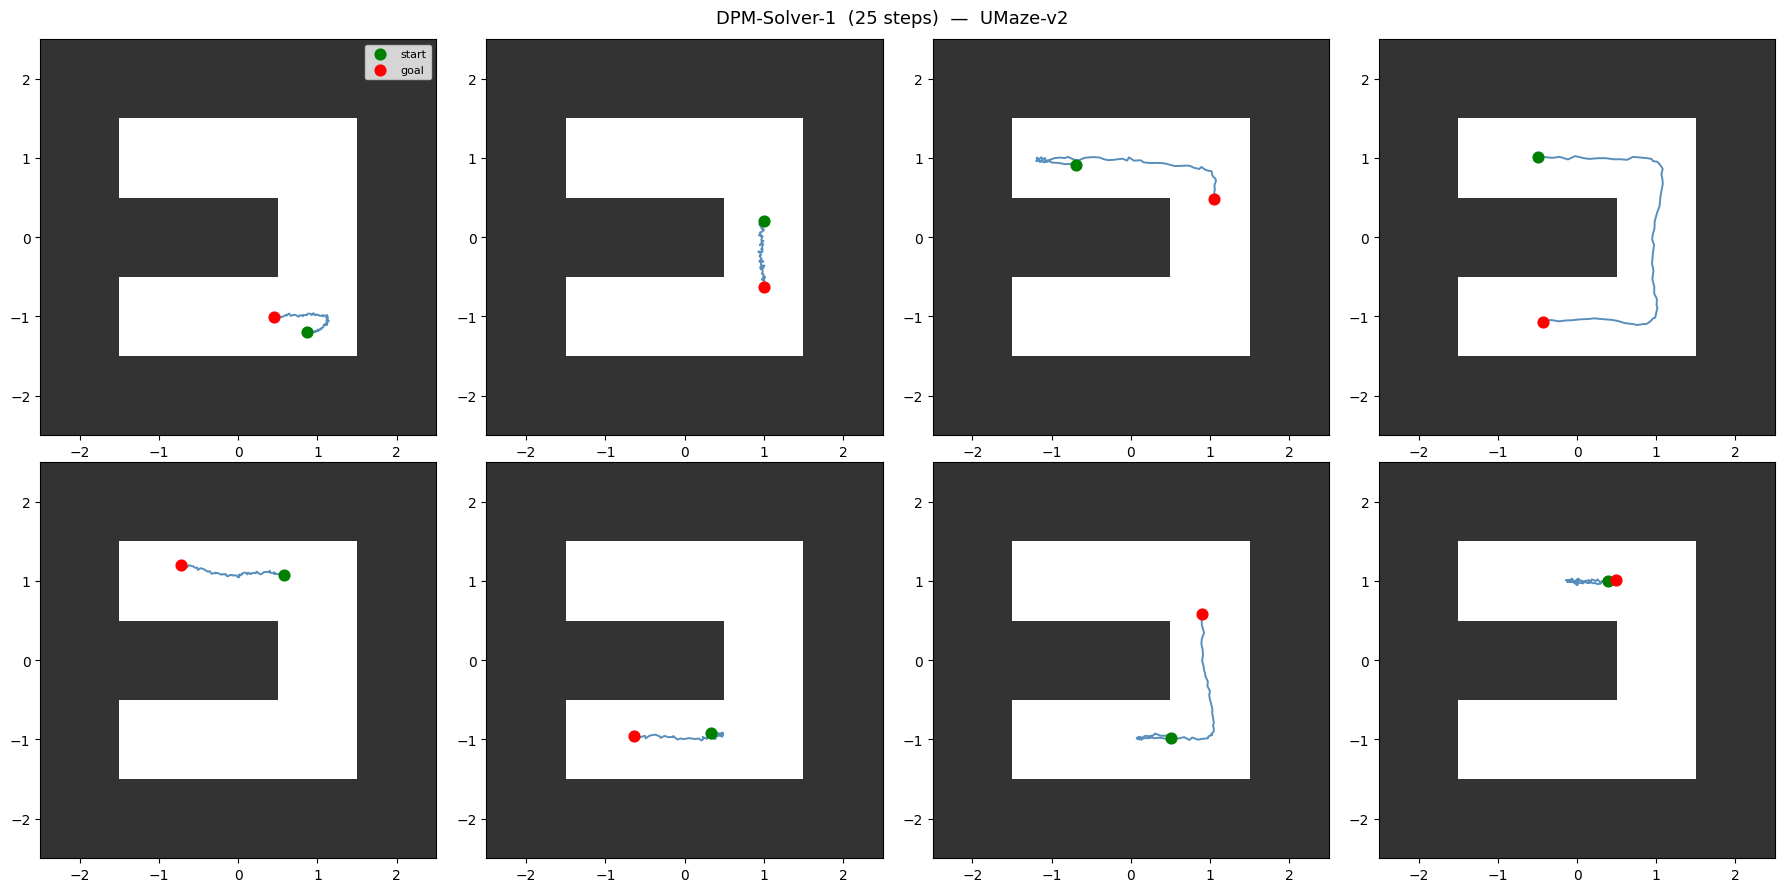

In [8]:
ema_model.eval()

rng_eval = np.random.default_rng(7)
eval_idx  = rng_eval.choice(len(ds), size=8, replace=False)
eval_batch = torch.stack([ds[i] for i in eval_idx])  # [8, T, 2] normalised
eval_xs = eval_batch[:, 0, :].to(device)              # [8, 2]
eval_xg = eval_batch[:, -1, :].to(device)             # [8, 2]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle(f'DPM-Solver-1  ({N_SAMPLE_STEPS} steps)  —  UMaze-v2', fontsize=13)

for j, ax in enumerate(axes.flat):
    xs_j = eval_xs[j:j+1]   # [1, 2]
    xg_j = eval_xg[j:j+1]   # [1, 2]

    samp = dpm_solver_1_sample(
        ema_model, ve,
        x_start=xs_j, x_goal=xg_j,
        T_steps=T_STEPS, n_steps=N_SAMPLE_STEPS,
        device=device,
    )  # [1, T, 2]

    world = ds.unnormalize(samp.cpu())     # [1, T, 2]
    xs_w  = ds.unnormalize(xs_j.cpu())    # [1, 2]
    xg_w  = ds.unnormalize(xg_j.cpu())   # [1, 2]

    render_maze_ax(ax, ds.maze_map, ds.cell_size)
    ax.plot(world[0, :, 0], world[0, :, 1], lw=1.4, color='steelblue', alpha=0.9)
    ax.scatter(xs_w[0, 0], xs_w[0, 1], c='green', s=60, zorder=6, label='start')
    ax.scatter(xg_w[0, 0], xg_w[0, 1], c='red',   s=60, zorder=6, label='goal')
    if j == 0:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 8. Loss Curve

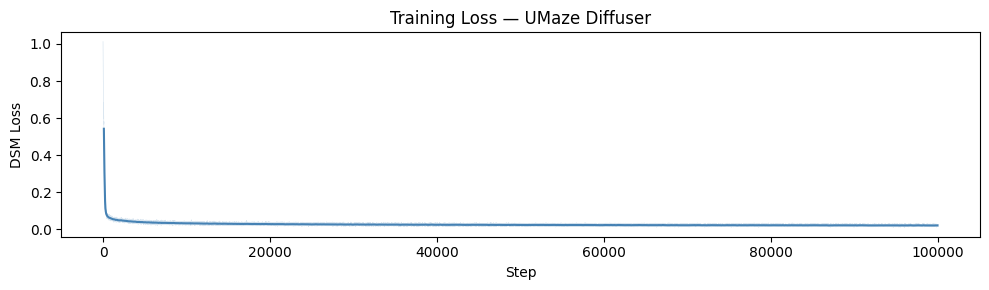

In [9]:
smooth = np.convolve(loss_history, np.ones(200) / 200, mode='valid')
plt.figure(figsize=(10, 3))
plt.plot(loss_history, alpha=0.2, color='steelblue', linewidth=0.5)
plt.plot(np.arange(len(smooth)) + 100, smooth, color='steelblue', linewidth=1.5)
plt.xlabel('Step'); plt.ylabel('DSM Loss')
plt.title('Training Loss — UMaze Diffuser')
plt.tight_layout()
plt.show()